In [310]:
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)

In [311]:
class SRNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=2, output_dim=1):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.context_dim = self.hidden_dim
        self.output_dim = output_dim

        self.in_to_hidden = nn.Linear(self.input_dim, self.hidden_dim)
        self.ctx_to_hidden = nn.Linear(self.context_dim, self.hidden_dim, bias=False) # in_to_hidden already has a bias
        self.hidden_to_out = nn.Linear(self.hidden_dim, self.output_dim)

    def init_context(self):
        return torch.full((self.hidden_dim,), 0.5)

    def forward(self, x, ctx):
        x1 = self.in_to_hidden(x)
        x2 = self.ctx_to_hidden(ctx)
        hidden = x1 + x2
        hidden_act = hidden.sigmoid()
        out = self.hidden_to_out(hidden_act)
        return out, hidden_act

In [312]:
def xor_sequence(n_triples):
    pairs = torch.randint(0, 2, (n_triples, 2))
    xor = pairs.sum(dim=1, keepdim=True) % 2
    return torch.cat([pairs, xor], dim=1).reshape(-1, 1).float()

seq = xor_sequence(1000)
X, y = seq[:-1], seq[1:]

In [313]:
hidden_dim = 2

model = SRNN(hidden_dim=hidden_dim)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Trainable parameters: 11


In [314]:
epochs = 150
lr = 0.1

optimiser = torch.optim.SGD(model.parameters(), lr=lr)
for epoch in range(1, epochs+1):
    ctx = model.init_context()
    loss_total = 0.0
    for x_item, y_item in zip(X, y):
        logits, hidden = model(x_item, ctx)
        prob = torch.sigmoid(logits)
        loss = F.mse_loss(prob, y_item)
        loss_total += loss.item()

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        ctx = hidden.detach()

    if epoch % 10 == 0:
        print(f"epoch {epoch:4d}  mean loss {loss_total / len(X):.4f}")

epoch   10  mean loss 0.2512
epoch   20  mean loss 0.2510
epoch   30  mean loss 0.2509
epoch   40  mean loss 0.2505
epoch   50  mean loss 0.2473
epoch   60  mean loss 0.2284
epoch   70  mean loss 0.2250
epoch   80  mean loss 0.2237
epoch   90  mean loss 0.2232
epoch  100  mean loss 0.2229
epoch  110  mean loss 0.2227
epoch  120  mean loss 0.2226
epoch  130  mean loss 0.2225
epoch  140  mean loss 0.2225
epoch  150  mean loss 0.2224


In [315]:
with torch.no_grad():
    ctx = model.init_context()
    probs = []
    for x_item in X:
        logits, hidden = model(x_item, ctx)
        probs.append(torch.sigmoid(logits))
        ctx = hidden
    probs = torch.stack(probs)

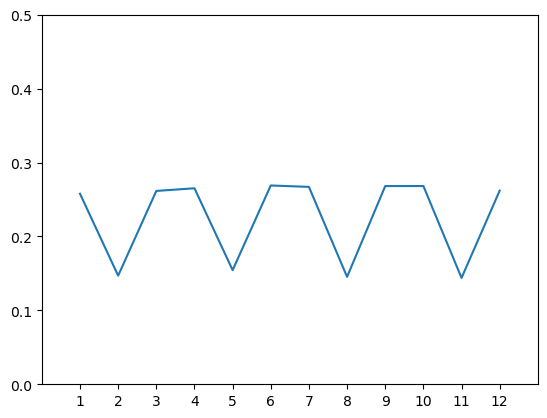

In [316]:
import matplotlib.pyplot as plt

squared_errors = (probs - y).square()
squared_errors = squared_errors[:(len(squared_errors)//12)*12]
phase_mse = squared_errors.reshape(-1, 12).mean(dim=0)
phase_rmse = phase_mse.sqrt()

xs = np.arange(1, len(phase_mse)+1)
plt.plot(xs, phase_mse)
plt.xticks(xs)
plt.xlim(0, 13)
plt.ylim(0, 0.5)

plt.show()

<img src="image.png" width="50%">

In [317]:
def letter_sequence(n_consonants):
    choices = ["ba", "dii", "guuu"]

    letter_seq = ""
    for _ in range(n_consonants):
        n = random.randint(0, 2)
        letter_seq += choices[n]

    return letter_seq

train_seq = letter_sequence(1000)
test_seq = letter_sequence(1000)

letter_to_vector = {
    "b": [1, 0, 1, 0, 0, 1],
    "d": [1, 0, 1, 1, 0, 1],
    "g": [1, 0, 1, 0, 1, 1],
    "a": [0, 1, 0, 0, 1, 1],
    "i": [0, 1, 0, 1, 0, 1],
    "u": [0, 1, 0, 1, 1, 1],
}

In [318]:
X_train = []
for i in range(len(train_seq)):
    X_train.append(letter_to_vector[train_seq[i]])
y_train = X_train[1:]+[X_train[0]]

X_train = torch.tensor(X_train).float()
y_train = torch.tensor(y_train).float()

X_test = []
for i in range(len(test_seq)):
    X_test.append(letter_to_vector[test_seq[i]])
y_test = X_test[1:]+[X_test[0]]

X_test = torch.tensor(X_test).float()
y_test = torch.tensor(y_test).float()

In [319]:
model = SRNN(input_dim=6, hidden_dim=20, output_dim=6)

epochs = 100

optimiser = torch.optim.SGD(model.parameters(), lr=lr)

ctx = model.init_context()
for epoch in range(1, epochs+1):
    loss_total = 0.0
    for x_item, y_item in zip(X_train, y_train):
        logits, hidden = model(x_item, ctx)
        prob = torch.sigmoid(logits)
        loss = F.mse_loss(prob, y_item)
        loss_total += loss.item()

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        ctx = hidden.detach()

    if epoch % 10 == 0:
        print(f"epoch {epoch:4d}  mean loss {loss_total / len(X_train):.4f}")


epoch   10  mean loss 0.0533
epoch   20  mean loss 0.0391
epoch   30  mean loss 0.0328
epoch   40  mean loss 0.0305
epoch   50  mean loss 0.0298
epoch   60  mean loss 0.0298
epoch   70  mean loss 0.0295
epoch   80  mean loss 0.0279
epoch   90  mean loss 0.0266
epoch  100  mean loss 0.0260


In [320]:
with torch.no_grad():
    ctx = model.init_context()
    probs = []
    for x_item in X_test:
        logits, hidden = model(x_item, ctx)
        probs.append(torch.sigmoid(logits))
        ctx = hidden
probs = torch.stack(probs)

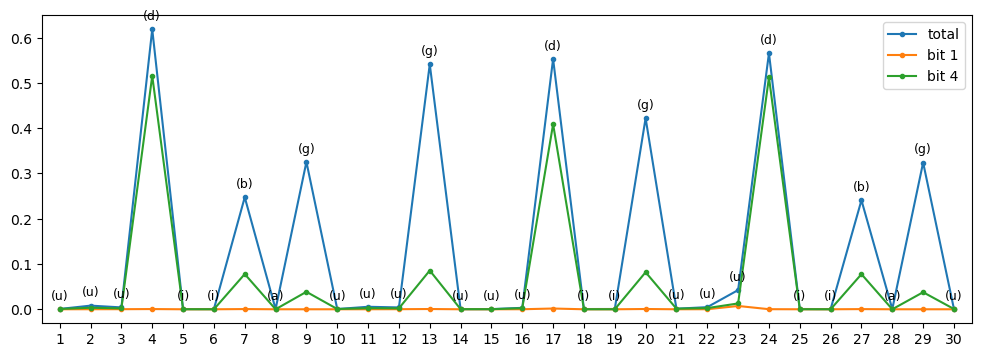

In [321]:
n = 30

total_errors = (probs - y_test).square().sum(dim=1)
bit1_errors = (probs - y_test).square()[:,0]
bit4_errors = (probs - y_test).square()[:,3]

positions = np.arange(n)

target_letters = list(test_seq[1:]) + [test_seq[0]]
target_letters = target_letters[n:2*n]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(
    positions,
    total_errors[n:2*n].cpu(),
    marker="o",
    markersize=3,
    label="total"
)
ax.plot(
    positions,
    bit1_errors[n:2*n].cpu(),
    marker="o",
    markersize=3,
    label="bit 1"
)
ax.plot(
    positions,
    bit4_errors[n:2*n].cpu(),
    marker="o",
    markersize=3,
    label="bit 4"
)

for position, letter, error in zip(
    positions,
    target_letters,
    total_errors[n:2*n],
):
    ax.annotate(
        f"({letter})",
        (position, error.item()),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_xticks(positions)
ax.set_xticklabels(positions + 1)
ax.margins(x=0.02)
plt.legend()
plt.show()

<img src="image2.png" width="50%">
<img src="image3.png" width="50%">
<img src="image4.png" width="50%">

In [322]:
LEXICON = {
    "NOUN-HUM":     ["man", "woman", "boy", "girl"],
    "NOUN-ANIM":    ["cat", "dog", "mouse"],
    "NOUN-INANIM":  ["book", "rock", "car"],
    "NOUN-AGRESS":  ["dragon", "monster", "lion"],
    "NOUN-FRAG":    ["glass", "plate"],
    "NOUN-FOOD":    ["cookie", "bread", "sandwich"],
    "VERB-INTRAN":  ["think", "sleep", "exist"],
    "VERB-TRAN":    ["see", "chase", "like"],
    "VERB-AGPAT":   ["move", "break"],
    "VERB-PERCEPT": ["smell", "see"],
    "VERB-DESTROY": ["break", "smash"],
    "VERB-EAT":     ["eat"],
}

TEMPLATES = [
    ("NOUN-HUM",    "VERB-EAT",     "NOUN-FOOD"),
    ("NOUN-HUM",    "VERB-PERCEPT", "NOUN-INANIM"),
    ("NOUN-HUM",    "VERB-DESTROY", "NOUN-FRAG"),
    ("NOUN-HUM",    "VERB-INTRAN"),
    ("NOUN-HUM",    "VERB-TRAN",    "NOUN-HUM"),
    ("NOUN-HUM",    "VERB-AGPAT",   "NOUN-INANIM"),
    ("NOUN-HUM",    "VERB-AGPAT"),
    ("NOUN-ANIM",   "VERB-EAT",     "NOUN-FOOD"),
    ("NOUN-ANIM",   "VERB-TRAN",    "NOUN-ANIM"),
    ("NOUN-ANIM",   "VERB-AGPAT",   "NOUN-INANIM"),
    ("NOUN-ANIM",   "VERB-AGPAT"),
    ("NOUN-INANIM", "VERB-AGPAT"),
    ("NOUN-AGRESS", "VERB-DESTROY", "NOUN-FRAG"),
    ("NOUN-AGRESS", "VERB-EAT",     "NOUN-HUM"),
    ("NOUN-AGRESS", "VERB-EAT",     "NOUN-ANIM"),
    ("NOUN-AGRESS", "VERB-EAT",     "NOUN-FOOD"),
]

In [323]:
random.seed(0)
torch.manual_seed(0)

word_to_bits = {}
count = 1
for words in LEXICON.values():
    for word in words:
        if word in word_to_bits.keys():
            continue
        bit = list(format(count, "031b"))
        word_to_bits[word] = np.array([int(b) for b in bit])
        count *= 2

templates = random.choices(TEMPLATES, k=10000)
sentences = []

for t in templates:
    words = []
    for word_type in t:
        word_list = LEXICON[word_type]
        words.append(random.choice(word_list))
    sentences.append(tuple(words))

import itertools

sentences_flat = list(itertools.chain.from_iterable(sentences))
X = [list(word_to_bits[s]) for s in sentences_flat]
y = torch.tensor(X[1:]).float()
X = torch.tensor(X[:-1]).float()

In [324]:
set_uni = set([sent[0] for sent in sentences])
cont_uni = {}
for uni in set_uni:
    cont_uni[uni] = {}
    for sent in sentences:
        if sent[0] != uni:
            continue
        cont = sent[1]
        if cont not in cont_uni[uni].keys():
            cont_uni[uni][cont] = 1
        else:
            cont_uni[uni][cont] += 1
like_uni = {}
for uni in set_uni:
    d = cont_uni[uni]
    d_count = sum(d.values())
    d = {k: v/d_count for k, v in d.items()}

    like_vector = np.zeros(31)
    for k in d.keys():
        like_vector += d[k] * word_to_bits[k]
    like_uni[uni] = like_vector

set_bi = set([sent[:2] for sent in sentences])
cont_bi = {}
for bi in set_bi:
    cont_bi[bi] = {}
    for idx, sent in enumerate(sentences):
        if sent[:2] != bi:
            continue

        if len(sent) == 2:
            if idx == len(sentences)-1:
                continue
            cont = sentences[idx+1][0]
        else:
            cont = sent[2]

        if cont not in cont_bi[bi].keys():
            cont_bi[bi][cont] = 1
        else:
            cont_bi[bi][cont] += 1
like_bi = {}
for bi in set_bi:
    d = cont_bi[bi]
    d_count = sum(d.values())
    d = {k: v/d_count for k, v in d.items()}

    like_vector = np.zeros(31)
    for k in d.keys():
        like_vector += d[k] * word_to_bits[k]
    like_bi[bi] = like_vector

from collections import Counter

start_words = [sentences[i+1][0] for i in range(len(sentences)) if i != len(sentences)-1 and len(sentences[i]) == 3]
d = Counter(start_words)
d_count = sum(d.values())
d = {k: v/d_count for k, v in d.items()}

like_vector = np.zeros(31)
for k in d.keys():
    like_vector += d[k] * word_to_bits[k]
like_tri = like_vector

likelihoods = []
for sent in sentences:
    likelihoods.append(like_uni[sent[0]])
    likelihoods.append(like_bi[sent[:2]])
    if len(sent) == 3:
        likelihoods.append(like_tri)
likelihoods = torch.tensor(np.array(likelihoods)[:-1])

In [353]:
torch.manual_seed(0)
model = SRNN(input_dim=31, hidden_dim=150, output_dim=31)

epochs = 5

lr = 0.05
optimiser = torch.optim.SGD(model.parameters(), lr=lr)

ctx = model.init_context()
for epoch in range(1, epochs+1):
    loss_total = 0.0
    for x_item, y_item in zip(X, y):
        logits, hidden = model(x_item, ctx)
        prob = torch.sigmoid(logits)
        loss = F.mse_loss(prob, y_item, reduction="sum")
        loss_total += loss.item()

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        ctx = hidden.detach()

    if epoch % 1 == 0:
        print(f"epoch {epoch:4d}  mean loss {loss_total / len(X):.4f}")


epoch    1  mean loss 0.9348
epoch    2  mean loss 0.8948
epoch    3  mean loss 0.8699
epoch    4  mean loss 0.8513
epoch    5  mean loss 0.8443


In [354]:
hiddens = []
with torch.no_grad():
    probs = []
    for x_item in X:
        logits, hidden = model(x_item, ctx)
        hiddens.append(hidden)
        probs.append(torch.sigmoid(logits))
        ctx = hidden
probs = torch.stack(probs)

In [355]:
mse = (probs - likelihoods).square().sum(dim=1)
print(mse.mean())

cosines = torch.cosine_similarity(probs, likelihoods)
print(cosines.mean())

tensor(0.0457, dtype=torch.float64)
tensor(0.8638, dtype=torch.float64)


In [356]:
hidden_dict = {}
for idx, hidden in enumerate(hiddens):
    word = sentences_flat[idx]
    if word not in hidden_dict.keys():
        hidden_dict[word] = [hidden]
    else:
        hidden_dict[word].append(hidden)

for k in hidden_dict.keys():
    hidden_dict[k] = torch.mean(torch.stack(hidden_dict[k]), dim=0)

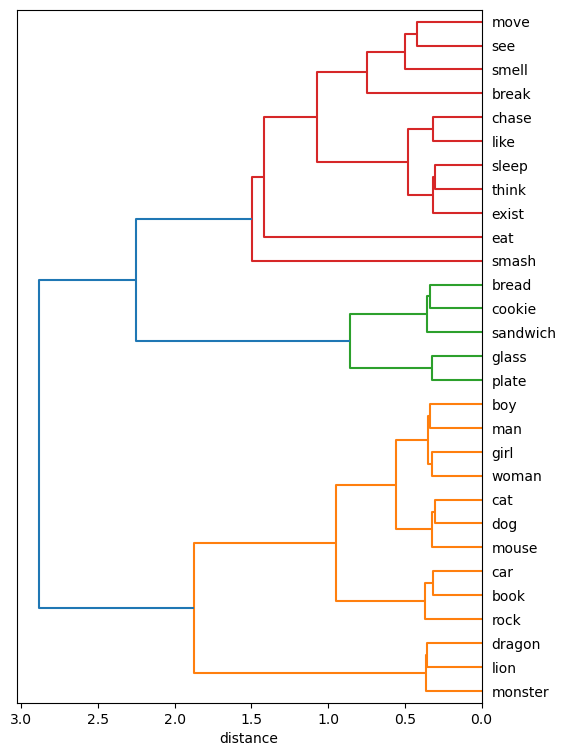

In [357]:
from scipy.cluster.hierarchy import linkage, dendrogram

words = list(hidden_dict.keys())
protos = torch.stack([hidden_dict[w] for w in words]).cpu().numpy()   # (29, 150)

Z = linkage(protos, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(6, 9))
dendrogram(Z, labels=words, orientation="left", ax=ax)
ax.set_xlabel("distance")
plt.show()

<img src="image5.png" width="50%">

In [358]:
word_to_bits_zog = word_to_bits.copy()
bit = list(format(count, "031b"))
word_to_bits_zog["zog"] = np.array([int(b) for b in bit])

sentences_flat_zog = ["zog" if x == "man" else x for x in sentences_flat]
X_zog = [list(word_to_bits_zog[s]) for s in sentences_flat_zog]
X_zog = torch.tensor(X_zog[:-1]).float()

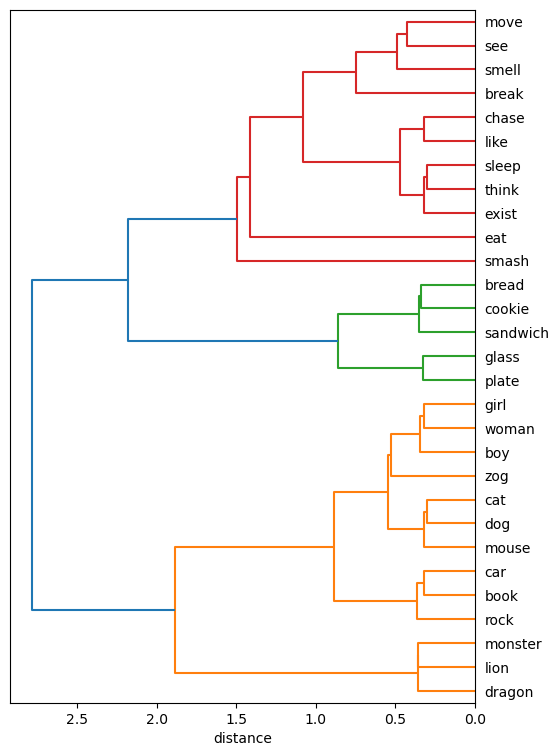

In [ ]:
# This effect is very fragile

hiddens_zog = []
with torch.no_grad():
    probs_zog = []
    for x_item in X_zog:
        logits, hidden = model(x_item, ctx)
        hiddens_zog.append(hidden)
        probs_zog.append(torch.sigmoid(logits))
        ctx = hidden
probs_zog = torch.stack(probs_zog)

hidden_dict_zog = {}
for idx, hidden in enumerate(hiddens_zog):
    word = sentences_flat_zog[idx]
    if word not in hidden_dict_zog.keys():
        hidden_dict_zog[word] = [hidden]
    else:
        hidden_dict_zog[word].append(hidden)

for k in hidden_dict_zog.keys():
    hidden_dict_zog[k] = torch.mean(torch.stack(hidden_dict_zog[k]), dim=0)

words = list(hidden_dict_zog.keys())
protos = torch.stack([hidden_dict_zog[w] for w in words]).cpu().numpy()   # (29, 150)

Z = linkage(protos, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(6, 9))
dendrogram(Z, labels=words, orientation="left", ax=ax)
ax.set_xlabel("distance")
plt.show()

<img src="image6.png" width="50%">